<a href="https://colab.research.google.com/github/Silly-Orb/Credit_Card_Fraud_Detection/blob/main/Credit_Card_Fraud_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Credit Card Fraud Detection Using Machine Learning

## Introduction

Credit card fraud is one of the most significant challenges faced by financial institutions today. Fraudulent transactions can result in substantial financial losses for both customers and banks.

This project aims to develop a machine learning model capable of identifying fraudulent credit card transactions based on historical transaction data.

## Objectives

- Analyze transaction data.
- Perform exploratory data analysis (EDA).
- Build machine learning models for fraud detection.
- Compare model performance.
- Evaluate results using classification metrics.

In [ ]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving creditcard.csv to creditcard.csv


In [ ]:
df = pd.read_csv("creditcard.csv")

In [ ]:
print("Dataset Loaded Successfully!")
print(df.shape)

Dataset Loaded Successfully!
(284807, 31)


In [ ]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [ ]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [ ]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


## Initial Observations

- Dataset contains 284,807 transactions.
- Total features = 31.
- Target variable = Class.
- Class = 0 indicates legitimate transaction.
- Class = 1 indicates fraudulent transaction.
- No missing values were found.
- Dataset is clean and ready for analysis.

## Exploratory Data Analysis (EDA)

In this section, we explore the dataset to understand the distribution of transactions and identify patterns related to fraudulent activities.

In [ ]:
df['Class'].value_counts()

,count
Class,
0,284315
1,492


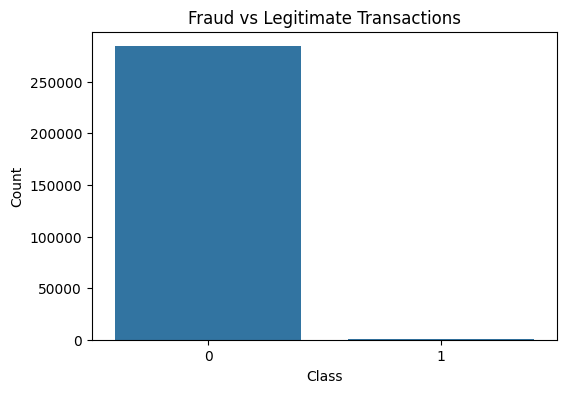

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(x='Class', data=df)

plt.title('Fraud vs Legitimate Transactions')
plt.xlabel('Class')
plt.ylabel('Count')

plt.show()

### Observation

The dataset is highly imbalanced.

Class 0 represents legitimate transactions and dominates the dataset.

Class 1 represents fraudulent transactions and forms only a tiny fraction of total transactions.

In [ ]:
fraud_count = df['Class'].value_counts()[1]
normal_count = df['Class'].value_counts()[0]

fraud_percentage = (fraud_count / len(df)) * 100

print("Fraud Transactions :", fraud_count)
print("Normal Transactions:", normal_count)
print("Fraud Percentage   :", round(fraud_percentage, 4), "%")

Fraud Transactions : 492
Normal Transactions: 284315
Fraud Percentage   : 0.1727 %


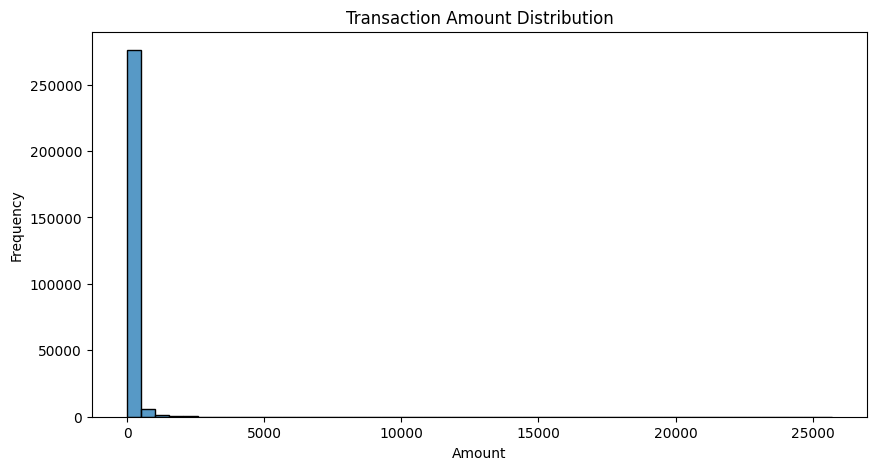

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(df['Amount'], bins=50)

plt.title('Transaction Amount Distribution')
plt.xlabel('Amount')
plt.ylabel('Frequency')

plt.show()

### Observation

Most transactions involve relatively small amounts.

A few transactions have very large amounts, creating a long-tail distribution.

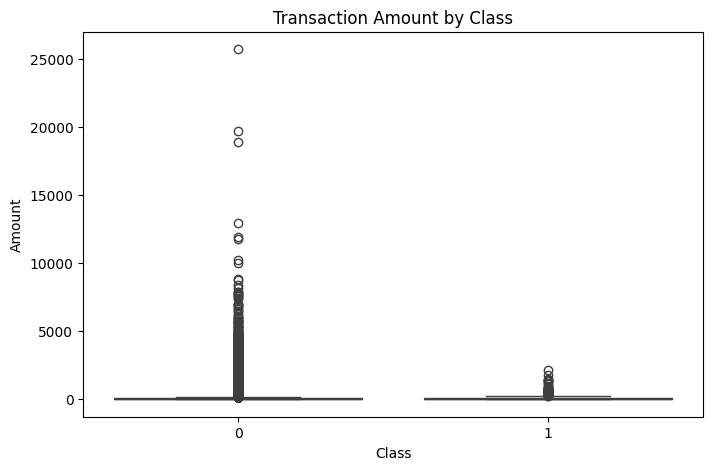

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Class', y='Amount', data=df)

plt.title('Transaction Amount by Class')

plt.show()

In [ ]:
df.groupby('Class')['Amount'].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


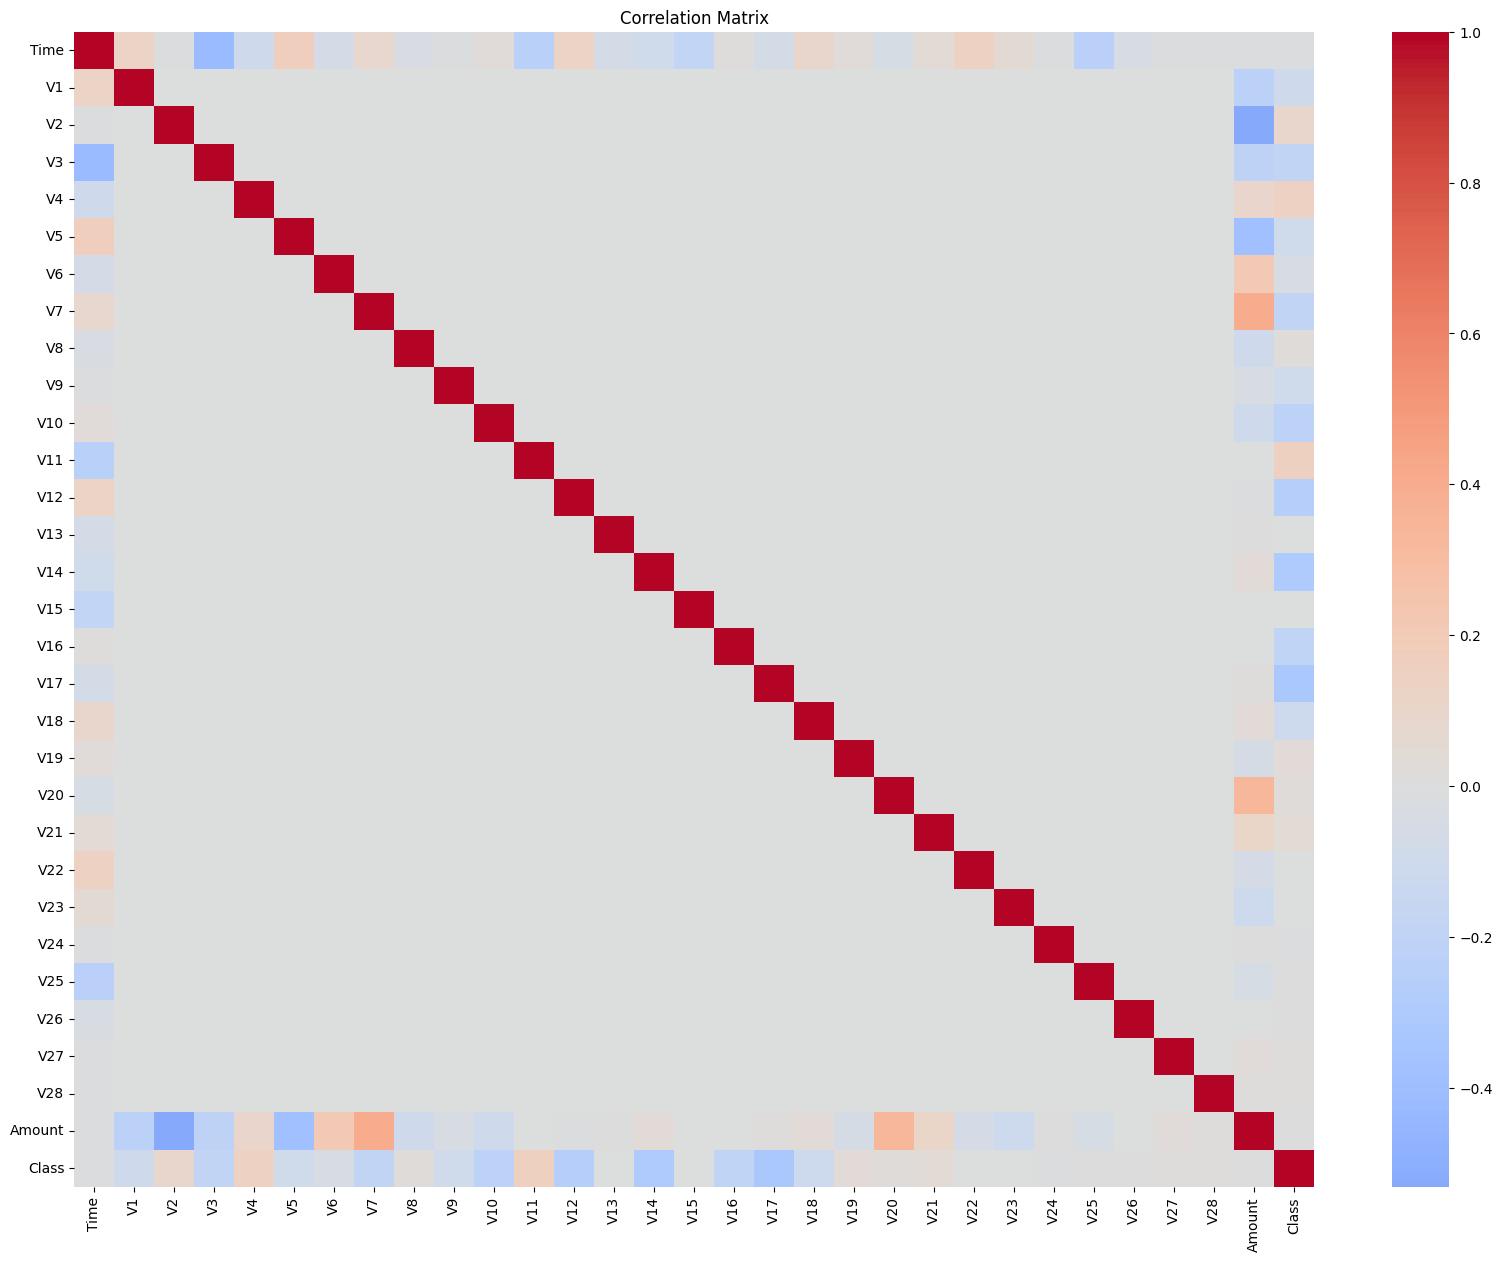

In [ ]:
corr_matrix = df.corr()

plt.figure(figsize=(20,15))

sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Matrix')

plt.show()

## Key Findings

- The dataset contains a very small percentage of fraudulent transactions.
- The dataset is highly imbalanced.
- Transaction amounts vary significantly.
- No missing values are present.
- Several features show relationships with each other and may help machine learning models identify fraud patterns.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df['scaled_amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))

df['scaled_time'] = scaler.fit_transform(df['Time'].values.reshape(-1, 1))

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V23,V24,V25,V26,V27,V28,Amount,Class,scaled_amount,scaled_time
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0,0.244964,-1.996583
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0,-0.342475,-1.996583
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,1.160686,-1.996562
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0,0.140534,-1.996562
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0,-0.073403,-1.996541


In [ ]:
df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,scaled_amount,scaled_time
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,0.244964,-1.996583
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,-0.342475,-1.996583
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,1.160686,-1.996562
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,0.140534,-1.996562
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0,-0.073403,-1.996541


In [ ]:
class_column = df.pop('Class')

df['Class'] = class_column


X = df.drop('Class', axis=1)

y = df['Class']


print(X.shape)
print(y.shape)

(284807, 30)
(284807,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)

Training Features : (227845, 30)
Testing Features  : (56962, 30)
Training Labels   : (227845,)
Testing Labels    : (56962,)


## Data Preprocessing

To improve model performance, the Time and Amount features were standardized using StandardScaler.

The original Time and Amount columns were removed after scaling.

The dataset was then divided into training and testing sets using an 80-20 split.

Stratified sampling was used to preserve the original fraud-to-normal transaction ratio.

## Logistic Regression Model

Logistic Regression is a supervised machine learning algorithm commonly used for binary classification problems.

In this project, it will classify transactions as either:

- Legitimate (0)
- Fraudulent (1)

In [ ]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression()

log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9991573329588147


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[56851    13]
 [   35    63]]


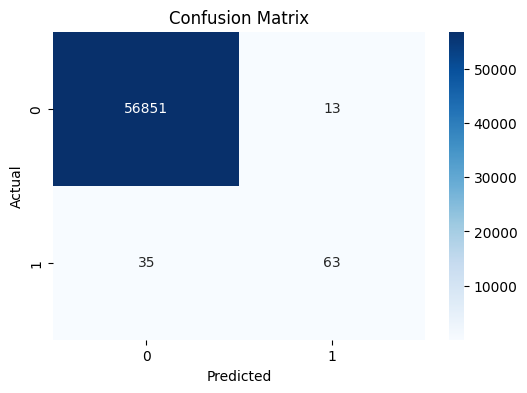

In [ ]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.64      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962



## Logistic Regression Results

The Logistic Regression model was trained on the processed dataset and evaluated using multiple classification metrics.

The model achieved high overall accuracy. However, because the dataset is highly imbalanced, additional metrics such as Precision, Recall, and F1-Score are more important for evaluating fraud detection performance.

## Logistic Regression Analysis

The Logistic Regression model achieved an accuracy of 99.91%.

The model successfully identified most legitimate transactions while maintaining a low false-positive rate.

For fraudulent transactions:

- Precision = 83%
- Recall = 64%
- F1-Score = 72%

Although overall accuracy is very high, the recall score indicates that some fraudulent transactions are still being missed. This suggests that further improvements are possible through advanced models and imbalance handling techniques.

## Decision Tree Classifier

Decision Trees classify data by repeatedly splitting it into smaller groups based on feature values.

They are capable of capturing non-linear patterns that Logistic Regression may miss.

Decision Tree Accuracy: 0.9990871107053826
[[56837    27]
 [   25    73]]


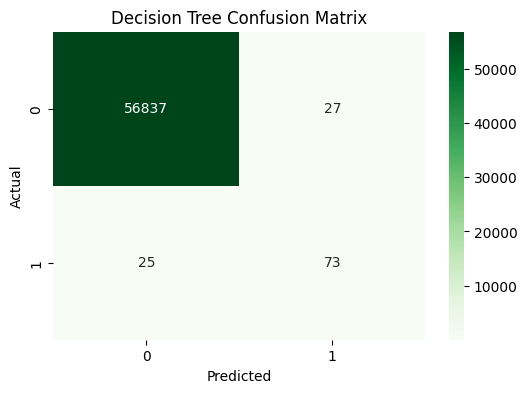

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

print(
    "Decision Tree Accuracy:",
    accuracy_score(y_test, dt_pred)
)

dt_cm = confusion_matrix(y_test, dt_pred)

print(dt_cm)

plt.figure(figsize=(6,4))

sns.heatmap(
    dt_cm,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("Decision Tree Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
print(
    classification_report(
        y_test,
        dt_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.73      0.74      0.74        98

    accuracy                           1.00     56962
   macro avg       0.86      0.87      0.87     56962
weighted avg       1.00      1.00      1.00     56962



## Decision Tree Analysis

The Decision Tree classifier demonstrated better fraud detection capability compared to Logistic Regression.

Results:

- Accuracy = 99.91%
- Precision = 73%
- Recall = 74%
- F1 Score = 74%

The model successfully identified 73 fraudulent transactions while missing only 25.

Although precision decreased slightly, recall improved significantly, making the model more effective for fraud detection.

Random Forest Accuracy: 0.9995962220427653
[[56859     5]
 [   18    80]]


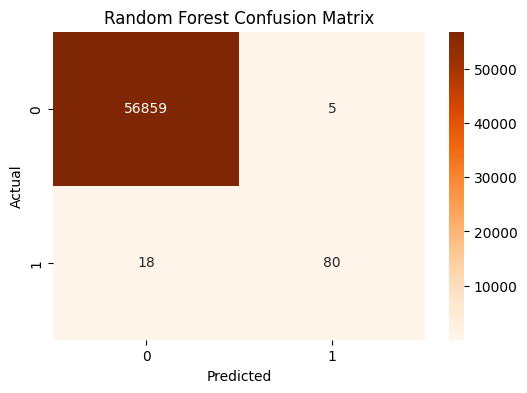

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

rf_cm = confusion_matrix(y_test, rf_pred)

print(rf_cm)

plt.figure(figsize=(6,4))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt='d',
    cmap='Oranges'
)

plt.title("Random Forest Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
print(
    classification_report(
        y_test,
        rf_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.94      0.82      0.87        98

    accuracy                           1.00     56962
   macro avg       0.97      0.91      0.94     56962
weighted avg       1.00      1.00      1.00     56962



## Random Forest Analysis

The Random Forest classifier achieved the best performance among all tested models.

Results:

- Accuracy = 99.96%
- Precision = 94%
- Recall = 82%
- F1 Score = 87%

The model successfully detected 80 out of 98 fraudulent transactions while generating only 5 false alarms.

Due to its superior fraud detection capability and overall balanced performance, Random Forest was selected as the final model for this project.

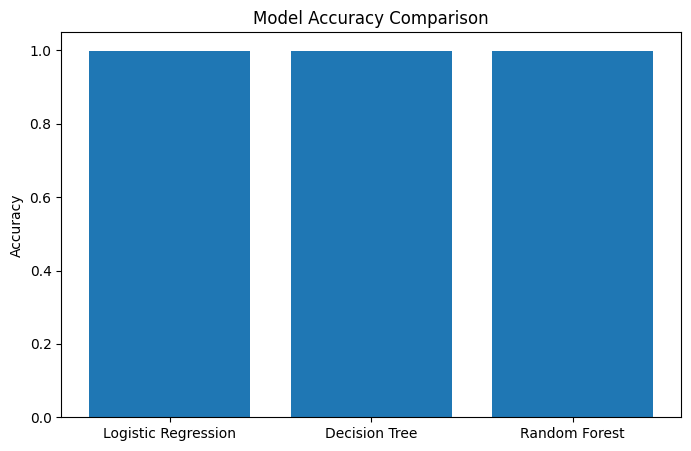

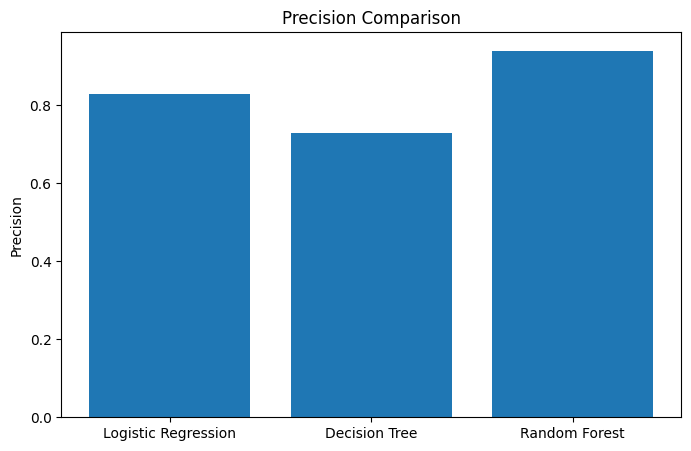

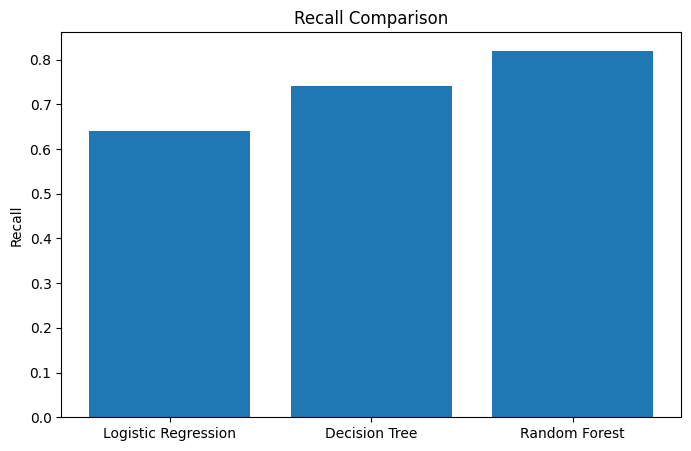

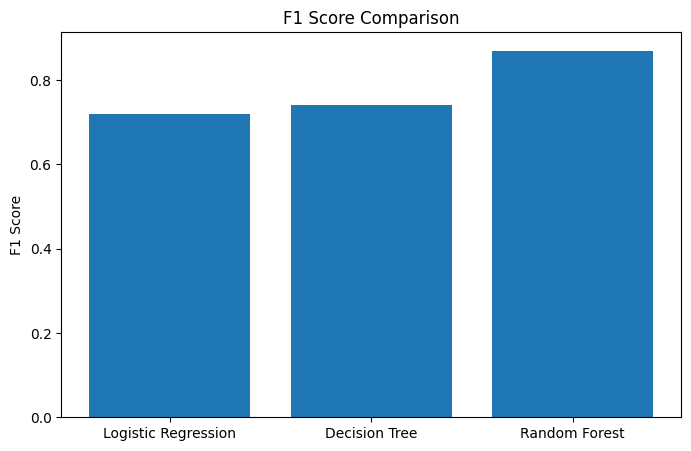

In [ ]:
models = [
    'Logistic Regression',
    'Decision Tree',
    'Random Forest'
]

accuracy = [
    0.999157,
    0.999087,
    0.999596
]

precision = [
    0.83,
    0.73,
    0.94
]

recall = [
    0.64,
    0.74,
    0.82
]

f1_score = [
    0.72,
    0.74,
    0.87
]

plt.figure(figsize=(8,5))

plt.bar(models, accuracy)

plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')

plt.show()

plt.figure(figsize=(8,5))

plt.bar(models, precision)

plt.title('Precision Comparison')
plt.ylabel('Precision')

plt.show()

plt.figure(figsize=(8,5))

plt.bar(models, recall)

plt.title('Recall Comparison')
plt.ylabel('Recall')

plt.show()

plt.figure(figsize=(8,5))

plt.bar(models, f1_score)

plt.title('F1 Score Comparison')
plt.ylabel('F1 Score')

plt.show()

# Conclusion

In this project, machine learning techniques were used to detect fraudulent credit card transactions.

Three classification algorithms were implemented and evaluated:

1. Logistic Regression
2. Decision Tree
3. Random Forest

Among all models, Random Forest demonstrated the best overall performance with:

- Accuracy: 99.96%
- Precision: 94%
- Recall: 82%
- F1 Score: 87%

The model successfully identified the majority of fraudulent transactions while maintaining a very low false-positive rate.

This project demonstrates the effectiveness of machine learning techniques in financial fraud detection and highlights the importance of handling highly imbalanced datasets.

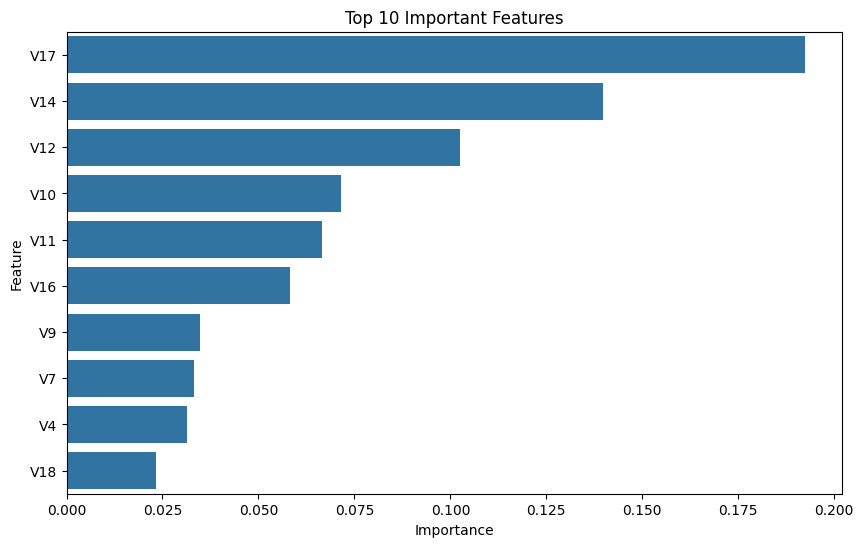

In [ ]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

top_features = feature_importance.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=top_features
)

plt.title("Top 10 Important Features")

plt.show()

## Feature Importance Analysis

Random Forest provides feature importance scores that indicate which variables contribute most to fraud detection.

The top features identified by the model play a significant role in distinguishing fraudulent transactions from legitimate ones.

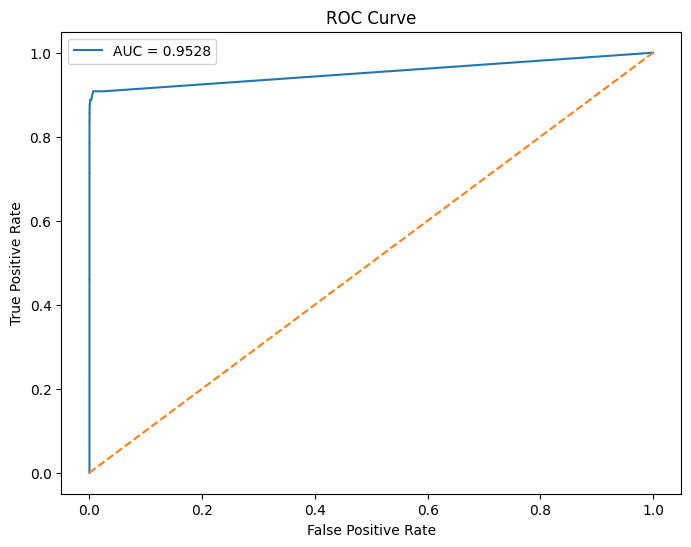

In [ ]:
from sklearn.metrics import roc_curve
from sklearn.metrics import auc

rf_probs = rf_model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(
    y_test,
    rf_probs
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.4f}"
)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [ ]:
def predict_transaction(transaction_data):

    prediction = rf_model.predict(
        [transaction_data]
    )

    if prediction[0] == 0:
        return "Legitimate Transaction"

    else:
        return "Fraudulent Transaction"



In [ ]:
sample = X_test.iloc[0]

predict_transaction(sample)

'Legitimate Transaction'

In [ ]:
import joblib

joblib.dump(
    rf_model,
    'credit_card_fraud_model.pkl'
)

loaded_model = joblib.load(
    'credit_card_fraud_model.pkl'
)

In [ ]:
comparison_df = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],

    'Accuracy': [
        0.999157,
        0.999087,
        0.999596
    ],

    'Precision': [
        0.83,
        0.73,
        0.94
    ],

    'Recall': [
        0.64,
        0.74,
        0.82
    ],

    'F1 Score': [
        0.72,
        0.74,
        0.87
    ]
})

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.999157,0.83,0.64,0.72
1,Decision Tree,0.999087,0.73,0.74,0.74
2,Random Forest,0.999596,0.94,0.82,0.87


# Future Scope

The current project can be further enhanced by:

- Applying SMOTE for class imbalance handling.
- Using XGBoost and LightGBM models.
- Implementing real-time fraud detection.
- Deploying the model as a web application.
- Integrating with banking transaction systems.

# Project Outcome

A machine learning-based fraud detection system was successfully developed and evaluated.

Among the tested algorithms, Random Forest achieved the best performance with:

- Accuracy: 99.96%
- Precision: 94%
- Recall: 82%
- F1 Score: 87%

The developed system can effectively identify suspicious transactions and assist financial institutions in reducing fraud-related losses.